# PYTHON ASSIGNMENT

# Table of Contents

1. **[Import Libraries](#lib)**
2. **[Data Understanding & Cleaning](#prep)**
    - 2.1 - **[Understand the Data](#read)**
    - 2.2 - **[Missing Value Treatment](#null)**
3.  **[Exploratory Data Analysis (EDA)](#prep)**
    - 3.1 - **[Understanding of Relations](#read)**
    - 3.2 - **[Analyze how addiction varies across demographics](#read)**
4. **[Aggregation & Insights](#prep)**
    - 4.1 - **[Gender](#read)**
    - 4.2 - **[Age Group](#read)**
    - 4.3 - **[Education Level](#read)**
5. **[Functions, Loops, and Conditionals](#prep)**
   - 5.1 - **[Classify risk level (Low/Medium/High) based on usage hours](#read)**
   - 5.2 - **[Suggest digital detox strategies using if-else blocks](#read)**
6. **[Storytelling Deliverable](#prep)**

# 1. Import Libraries

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

***

# 2. Data Understanding & Cleaning

In [2]:
# Load the dataset
try:
    df = pd.read_csv('../data/student_addiction_data.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: The dataset file was not found. Please check the file path.")

Dataset loaded successfully.


In [3]:
# Preview first 5 rows
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [4]:
# Data Understanding
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: fl

In [5]:
# Summary statistics
df.describe()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,353.000000,20.659574,4.918723,6.868936,6.226950,2.849645,6.436879
std,203.660256,1.399217,1.257395,1.126848,1.105055,0.957968,1.587165
min,1.000000,18.000000,1.500000,3.800000,4.000000,0.000000,2.000000
25%,177.000000,19.000000,4.100000,6.000000,5.000000,2.000000,5.000000
50%,353.000000,21.000000,4.800000,6.900000,6.000000,3.000000,7.000000
75%,529.000000,22.000000,5.800000,7.700000,7.000000,4.000000,8.000000
max,705.000000,24.000000,8.500000,9.600000,9.000000,5.000000,9.000000


In [6]:
# Dataset shape
df.shape

(705, 13)

In [7]:
# List column names
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country',
       'Avg_Daily_Usage_Hours', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Relationship_Status',
       'Conflicts_Over_Social_Media', 'Addicted_Score'],
      dtype='object')

In [8]:
# Handle missing values, if any
df.isnull().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
dtype: int64

### Interpretation :- There are no missing values in the DATAFRAME. So , we can proceed with our Analysis.

In [9]:
df.duplicated().sum() # There are no duplicate values in the DATAFRAME

np.int64(0)

In [10]:
# Perform appropriate data type conversions if required
df.dtypes

Student_ID                        int64
Age                               int64
Gender                           object
Academic_Level                   object
Country                          object
Avg_Daily_Usage_Hours           float64
Most_Used_Platform               object
Affects_Academic_Performance     object
Sleep_Hours_Per_Night           float64
Mental_Health_Score               int64
Relationship_Status              object
Conflicts_Over_Social_Media       int64
Addicted_Score                    int64
dtype: object

### Interpretation: Since the inspection showed that all data types were already appropriate for the subsequent mathematical and categorical analysis, no manual conversion is required.

***

# 3. Exploratory Data Analysis (EDA)

### ○ Understanding of Relations

<Figure size 1000x300 with 0 Axes>

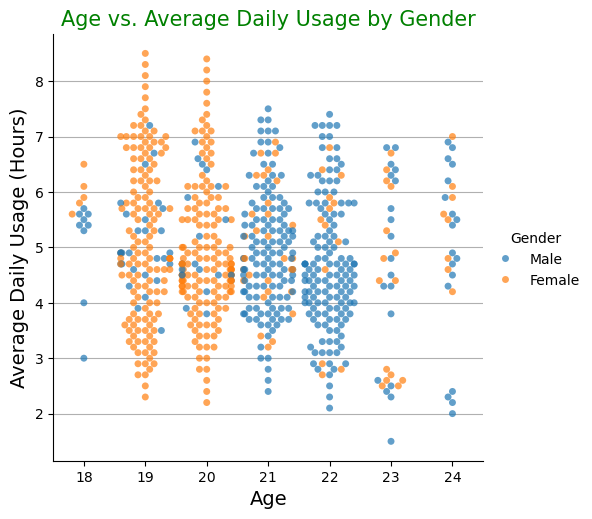

In [12]:
# Age, Gender, Daily Usage (in hours) using catplot

plt.figure(figsize=(10,3))
sns.catplot(data=df, x='Age', y='Avg_Daily_Usage_Hours', hue='Gender',kind="swarm", alpha=0.7)
plt.title('Age vs. Average Daily Usage by Gender',size=15,color='green')
plt.xlabel('Age',size=14)
plt.ylabel('Average Daily Usage (Hours)',size=14)
plt.grid(axis='y')
plt.show()

####  Interpretation : From this Catplot, we can conclude that females between the age of 19 and 20 have the highest average social media use.On the other hand, males are most addicted to social media at the age of 21 and 22.

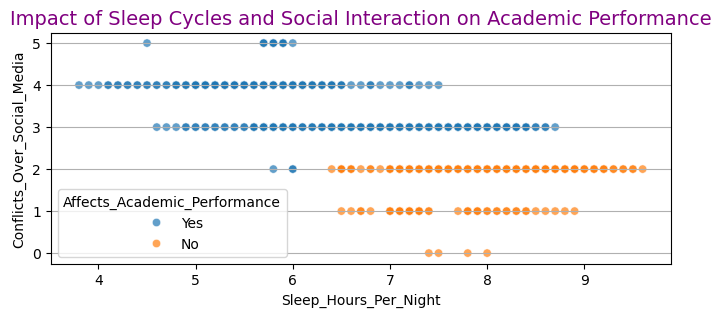

In [14]:
# Sleep patterns, Academic performance, Social interaction using Scatterplot

plt.show()
plt.figure(figsize=(8,3))
sns.scatterplot(data=df, x='Sleep_Hours_Per_Night', y='Conflicts_Over_Social_Media', hue='Affects_Academic_Performance', alpha=0.7)
plt.title('Impact of Sleep Cycles and Social Interaction on Academic Performance',size=14,color='purple')
plt.xlabel('Sleep_Hours_Per_Night')
plt.ylabel('Conflicts_Over_Social_Media')
plt.legend(title='Affects_Academic_Performance')
plt.grid(axis='y')
plt.show()

#### Interpretation: From this Scatterplot, we can conclude that students who had more than two social media conflicts not only had their academic scores affected but also experienced disrupted sleep cycles.

### ○ Analyze How Addiction Varies Across Demographics

Text(0.5, 1.0, 'Addiction Score by Age and Gender')

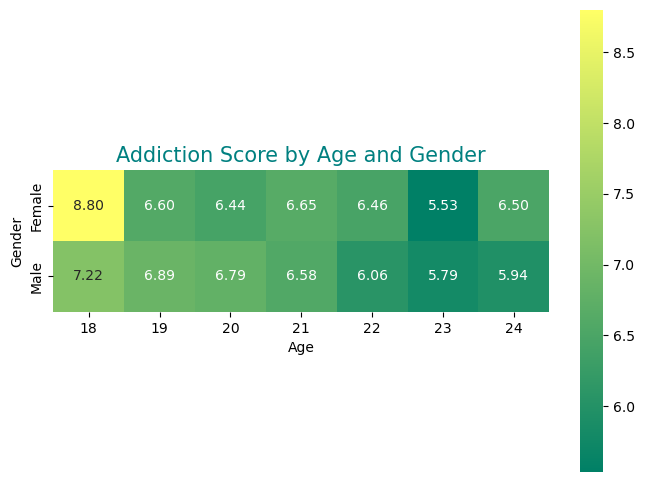

In [16]:
# Addiction rate based on age and gender using Heatmap (1)

df4=pd.pivot_table(df, index='Gender', columns='Age', values='Addicted_Score', aggfunc= "mean")
plt.figure(figsize=(8,6))
sns.heatmap(
    df4,
    square=True,
    annot=True,
    fmt='.2f',
    cmap='summer'
    )
plt.title("Addiction Score by Age and Gender", color="teal",size=15)

#### Interpretation: This Heatmap shows that the overall addiction level for female students exceeds that of male students, with females aged 18, 21, 22, and 24 leading the addiction to social media. 

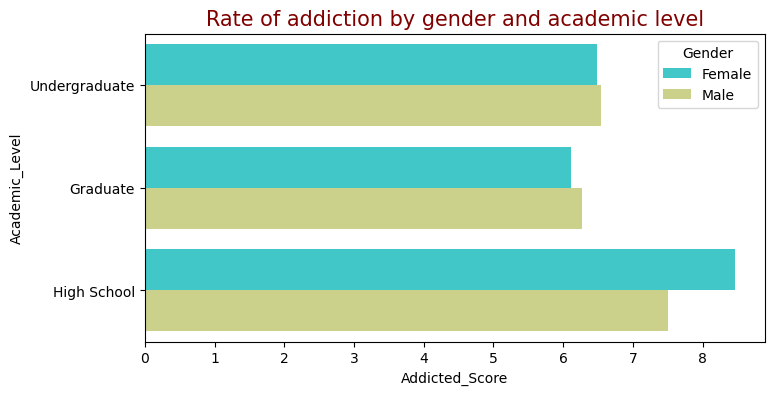

In [18]:
# Addiction rate based on gender and academic level using horizontal bar plot (2)

plt.figure(figsize=(8,4))
sns.barplot(y=df['Academic_Level'],x=df['Addicted_Score'],hue=df['Gender'],errorbar=None,palette='rainbow')
plt.title('Rate of addiction by gender and academic level',size=15,color='maroon')
plt.show()

#### Interpretation: This Barplot shows that the addiction rate among females at the High School level surpasses that of males, while at the Graduate level and Undergraduate level, males exhibit greater social media addiction than females.

<function matplotlib.pyplot.show(close=None, block=None)>

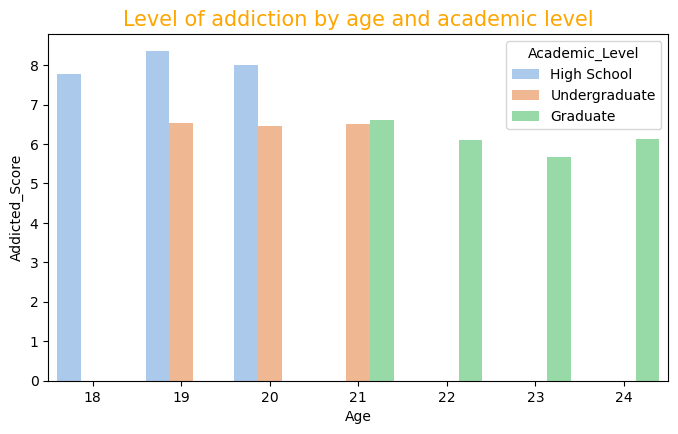

In [20]:
# Addiction rate based on age and academic level using bar plot (3)

plt.figure(figsize=(8,4.5))
sns.barplot(x=df['Age'],y=df['Addicted_Score'],hue=df['Academic_Level'],errorbar=None,palette='pastel')
plt.title('Level of addiction by age and academic level',size=15,color='orange')
plt.show

#### Interpretation: This Barplot shows that High School students exhibit the highest addiction levels, whereas Undergraduates display the lowest level of addiction, and Graduate students also experience a significantly high level of social media addiction.

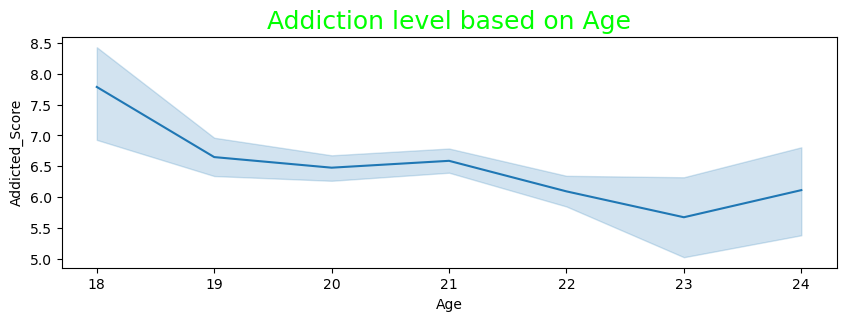

In [22]:
# Addiction rate based on age Lineplot (4)

plt.figure(figsize=(10,3))
sns.lineplot(x='Age',y='Addicted_Score',data=df)
plt.title('Addiction level based on Age',color='lime',size=18)
plt.show()

#### Interpretation: The Lineplot shows that students aged 18 and over are the most impacted by social media addiction, while a sudden increase in addiction levels has been noted among students aged 24.

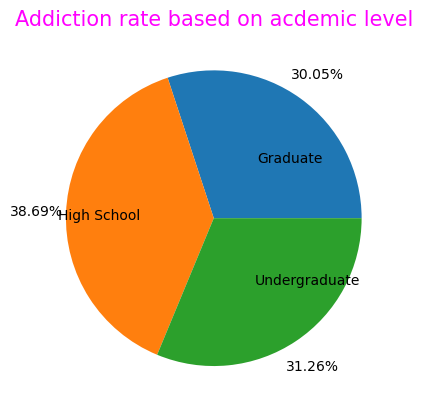

In [24]:
# Addiction rate based on academic level using pie chart (5)

df5=df.groupby('Academic_Level')['Addicted_Score'].mean()
plt.pie(df5.values,labels=df5.index,autopct='%.2f%%',pctdistance=1.2,
       labeldistance=0.5)
plt.title('Addiction rate based on acdemic level',color='magenta',size=15)
plt.show()

#### Interpretation: The pie chart shows that High School students are the most impacted by addiction, followed by Undergraduate students, while Graduate students are the least impacted.

***

# 4. Aggregation & Insights

### ○ Gender

In [25]:
# Using Groupby Function for Gender wise Addiction Score (Mean)
df.groupby('Gender')['Addicted_Score'].mean().sort_values(ascending=False) # Sorting based on Mean

Gender
Female    6.515581
Male      6.357955
Name: Addicted_Score, dtype: float64

#### Interpretation: Female students have an average addiction score of 6.52, while male students have 6.36. In other words, in this dataset female students show a slightly higher average addiction score than male students (though the difference is small). This is found simply by grouping by gender and taking the mean.

### ○ Age Group

In [26]:
# Function to create age groups
def age_group(age):
    if age < 18:
        return 'Under 18'
    elif 18 <= age <= 22:
        return '18-22'
    elif 23 <= age <= 26:
        return '23-26'
    else:
        return '27+'

df['AgeGroup'] = df['Age'].apply(age_group)

In [27]:
# Using Groupby and Aggregate for Addiction Score based on Age Group 
df1=df.groupby('AgeGroup').agg({'Addicted_Score':['mean','count']})
df1

Addicted_Score      
                   mean count
AgeGroup                     
18-22          6.489922   645
23-26          5.866667    60

#### Interpretation: We see the average addiction score for the 18–22 age group is 6.49, and for 23–26 it is 5.87. (In this dataset there are no students under 18 or age 27+, so those groups had no data and were dropped.) This tells us that the younger group (18–22) has a slightly higher average addiction score than the older group (23–26) in our data.

### ○ Education Level

In [28]:
# Using groupby and aggregate to calculate addiction score based on academic level
df2 = df.groupby('Academic_Level')['Addicted_Score'].agg(['mean','count']).sort_values(by='mean', ascending=False) # Sorting based on Mean
df2

,mean,count
Academic_Level,,
High School,8.037037,27
Undergraduate,6.492918,353
Graduate,6.243077,325


#### Interpretation: Here the High School group has the highest average addiction score (8.04), while Undergraduate is 6.49 and Graduate is 6.24. This suggests that, in this data, students whose highest education is high school report higher addiction scores on average than those in college or graduate school.

***

# 5. Functions, Loops, and Conditionals

### ○ Classify risk level (Low/Medium/High) based on usage hours

In [29]:
# Using max function to evaluate maximum Average Daily Usage
df.Avg_Daily_Usage_Hours.max()

8.5

In [30]:
# Using max function to evaluate minimum Average Daily Usage
df.Avg_Daily_Usage_Hours.min()

1.5

In [35]:
# Function that asks user for daily usage and classifies risk
def classify_risk():
    hours = float(input("Enter daily social media usage in hours: "))
    if hours < 3:
        print (f"{hours} hrs/day - Low Risk")
    elif 3 <= hours <= 5:
        print (f"{hours} hrs/day - Medium Risk")
    else:
        print (f"{hours} hrs/day - High Risk")
# Run the function
classify_risk()

1.0 hrs/day - Low Risk


### ○ Suggest digital detox strategies using if-else blocks

In [37]:
# Function for classifying risk + giving detox advice
def detox_advice(hours):
    if hours < 3:
        risk = 'Low'
        advice = "Maintain balance and Limit unnecessary scrolling."
    elif 3 <= hours <= 5:
        risk = 'Medium'
        advice = "Set screen time reminders and Take a short 15 minutes offline breaks."
    else:
        risk = 'High'
        advice = "Try a digital detox day and Avoid phone before bed and switch off notifications."
    return risk, advice
    
# Loop with input from user
n = int(input("How many students do you want to check? "))

for i in range(n):
    hours = float(input(f"Enter daily usage (in hours) for Student {i+1}: "))
    risk, advice = detox_advice(hours)
    print(f"Student {i+1}: {hours} hrs/day - {risk} Risk - Advice: {advice}")
    print("---------------------------------------------------------------------")

Student 1: 1.0 hrs/day - Low Risk - Advice: Maintain balance and Limit unnecessary scrolling.
---------------------------------------------------------------------
Student 2: 2.0 hrs/day - Low Risk - Advice: Maintain balance and Limit unnecessary scrolling.
---------------------------------------------------------------------


***

# 6. Storytelling Deliverable :

### The social media addiction among the students that is analyzed from the relevant data shows that there are several noteworthy trends. The statistics also show that the average score on addictions (6.52) among female students is higher than that of male students (6.36). In particular, the most frequent number of hours in usage is expressed by females aged 19 to 20. The highest means of addiction scores lies with the High School students (8.04), then Undergraduates (6.49) lastly the Graduates (6.24). Addiction levels among 24-year-old students have also risen significantly. The essential connection was observed to exist between high scores on conflict on social media (over two conflicts) and adverse effects on academic performance and the sleep cycle.

### The following trends indicate some possible root causes. This data suggests that younger students, especially high school pupils, might not possess the digital literacy and the ability to successfully regulate and manage social media use. The correlation between social media disputes, poor sleep and low academic achievement, as observed, suggests that emotional burden and time disposal of such interactions are directly leading to a compromise in well being and academic concentration. This data is likely to change as the students mature and enter graduate-level education where the gradual to lower addictions levels are seen average suggesting that they become more mature and more focused on academics. Nonetheless, the peak on age 24 is a certain spot that needs to be explored further.

### In light of these observations, some measures may be prescribed to counter social media addiction. When one is now classified as being in the high-risk category (spends over 5 hours a day on social media), interventions such as a digital detox day and disabling notifications are recommended. The Medium Risk group (3-5 hours/day) will help students by establishing reminders about screen time and spending brief and timed screen breaks in between. Moreover, the Government should take some actions against these social media apps or put a time limit or creation of policy which may help reduce the addiction of these students. These measures, along with the popularization of overall digital welfare, are likely to make students restore their power to use social media.